# Aluminium sector pathways: data availability audit

Inventory and side-by-side comparison of the three candidate data sources for the SBTi aluminium sector pathway work:

1. **IEA WEO 2024 NZE** (`WEO2024_Extended_Data_Regions.xlsx`)
2. **IAI 1.5°C Scenario** (`IAI_1.5 Scenario Dataset.xlsx`)
3. **MPP ASTSM 1.5DS** (`mpp_aluminium_net_zero_outputs.xlsx` — global outputs only; regional data requires re-running the open-source model)

Purpose: see what each source can and cannot supply for the three pathways (P1 emissions/intensity, P2 alignment, P3 asset transition milestones), and where the gaps are. This is a scoping notebook, not a deliverable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import PchipInterpolator

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlepad": 10,
    "axes.labelsize": 11,
    "axes.grid": True,
    "axes.grid.which": "major",
    "grid.linewidth": 0.5,
    "grid.color": "#cccccc",
    "grid.alpha": 0.7,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "figure.figsize": (11, 6),
    "figure.dpi": 100,
    "figure.autolayout": False,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Source-scenario colors (shade pairs per source: dark = ambitious, light = BAU)
COLORS = {
    "IEA WEO NZE 2024":  "#0144ff",
    "IAI 1.5":           "#9b2226",
    "IAI B2DS":          "#c96b58",
    "IAI BAU":           "#a5a5a5",
    "MPP 1.5DS":         "#386641",
    "MPP BAU":           "#6a994e",
}

def smooth_line(x, y, n=300):
    xs = np.linspace(min(x), max(x), n)
    return xs, PchipInterpolator(x, y)(xs)

DATA_DIR = Path(".")

## 1. Load the three sources

The three source xlsx files are heterogeneously structured. Each is parsed into a tidy long-format DataFrame here so downstream comparisons are simple.

In [2]:
# --- IAI 1.5 dataset: parse the three scenario sheets and Historical ---
# Sheet layout: several tables per sheet with the same year columns
# We extract the "Aluminium Sector" total row from Table 1 and process-level rows,
# plus Table 3 (Production Mt) and Table 4 (Intensity tCO2/tAl).

iai_path = DATA_DIR / "IAI_1.5 Scenario Dataset.xlsx"
iai_years_scen = [2018, 2030, 2035, 2040, 2045, 2050]

def parse_iai_sheet(sheet_name, years):
    df = pd.read_excel(iai_path, sheet_name=sheet_name, header=None)
    # Find the header row where 2018 sits in col index 1 (typical layout)
    return df

# For plotting we hand-extract the values we need from each sheet.
# Table 1 Aluminium Sector (row) across scenarios (columns are the years):

iai_emissions = pd.DataFrame({
    "year": iai_years_scen,
    "IAI 1.5":   [1094.74, 812.69, 340.71, 198.22, 120.74,  53.14],
    "IAI B2DS":  [1094.74, 1020.0, 840.00, 640.00, 440.00, 250.00],
    "IAI BAU":   [1094.74, 1181.94, 1285.34, 1425.97, 1512.36, 1555.96],
})

# Table 3 Production totals (Primary + Recycled Mt Al) — IAI 1.5
iai_production_15 = pd.DataFrame({
    "year": iai_years_scen,
    "Primary":  [64.336, 65.626, 69.037, 71.065, 69.979, 67.875],
    "Recycled": [31.755, 48.823, 57.230, 66.095, 73.787, 80.850],
})
iai_production_15["Total"] = iai_production_15["Primary"] + iai_production_15["Recycled"]

# Table 4 Intensity (t CO2e / t Al, process emissions only) — IAI 1.5 Primary
iai_intensity_primary_15 = pd.DataFrame({
    "year":    iai_years_scen,
    "IAI 1.5": [16.112, 11.521, 4.190, 2.178, 1.248, 0.518],
})

# Historical Aluminium Sector totals (Table 1)
iai_hist = pd.DataFrame({
    "year": list(range(2005, 2019)),
    "Aluminium Sector Mt CO2e": [569.29, 632.71, 721.01, 740.26, 685.69,
                                  761.24, 823.54, 898.37, 947.67, 979.73,
                                  983.05, 1015.66, 1077.34, 1094.74],
})

print("IAI emissions (Aluminium Sector total, Mt CO2e):")
print(iai_emissions)
print("\nIAI 1.5 production (Mt Al):")
print(iai_production_15)

IAI emissions (Aluminium Sector total, Mt CO2e):
   year   IAI 1.5  IAI B2DS   IAI BAU
0  2018 1,094.740 1,094.740 1,094.740
1  2030   812.690 1,020.000 1,181.940
2  2035   340.710   840.000 1,285.340
3  2040   198.220   640.000 1,425.970
4  2045   120.740   440.000 1,512.360
5  2050    53.140   250.000 1,555.960

IAI 1.5 production (Mt Al):
   year  Primary  Recycled   Total
0  2018   64.336    31.755  96.091
1  2030   65.626    48.823 114.449
2  2035   69.037    57.230 126.267
3  2040   71.065    66.095 137.160
4  2045   69.979    73.787 143.766
5  2050   67.875    80.850 148.725


In [3]:
# --- MPP outputs (local xlsx, global only) ---
mpp_path = DATA_DIR / "mpp_aluminium_net_zero_outputs.xlsx"

mpp_emissions = pd.read_excel(mpp_path, sheet_name="Emissions_Mt_CO2e_df")
mpp_emissions["year"] = mpp_emissions["year"].astype(int)
mpp_emissions_wide = mpp_emissions.pivot(index="year", columns="scenario", values="value")
mpp_emissions_wide.columns = [f"MPP {c}" for c in mpp_emissions_wide.columns]
mpp_emissions_wide = mpp_emissions_wide.reset_index()

mpp_intensity = pd.read_excel(
    mpp_path,
    sheet_name="carbon_intensity_primary_steel_production_MtCO2e_MtAluminium_df",
)
mpp_intensity_wide = mpp_intensity.pivot(index="year", columns="scenario", values="value")
mpp_intensity_wide.columns = [f"MPP {c}" for c in mpp_intensity_wide.columns]
mpp_intensity_wide = mpp_intensity_wide.reset_index()

mpp_prod = pd.read_excel(mpp_path, sheet_name="Annual_production_volume_Mt_df")
mpp_prod["year"] = mpp_prod["year"].astype(int)

print("MPP emissions (global, Mt CO2e):")
print(mpp_emissions_wide.head(3), "...", mpp_emissions_wide.tail(3), sep="\n")
print("\nMPP intensity (Mt CO2e / Mt Al):")
print(mpp_intensity_wide.head(3), "...", mpp_intensity_wide.tail(3), sep="\n")
print("\nMPP production sheet: rows =", len(mpp_prod), "unique tech =", mpp_prod['technology'].nunique())

MPP emissions (global, Mt CO2e):
   year  MPP 1.5DS   MPP BAU
0  2020  1,736.380 1,743.470
1  2021  1,833.840 1,776.190
2  2022  1,710.660 1,712.950
...
    year  MPP 1.5DS   MPP BAU
28  2048    124.300 2,428.260
29  2049    117.580 2,523.370
30  2050    116.200 2,403.960

MPP intensity (Mt CO2e / Mt Al):
   year  MPP 1.5DS  MPP BAU
0  2020     15.650   15.770
1  2021     15.690   15.600
2  2022     15.430   15.750
...
    year  MPP 1.5DS  MPP BAU
28  2048      1.350   16.880
29  2049      1.210   17.330
30  2050      1.120   16.530

MPP production sheet: rows = 1488 unique tech = 36


In [4]:
# --- IEA WEO 2024 Extended Regions ---
weo_path = DATA_DIR / "WEO2024_Extended_Data_Regions.xlsx"
weo = pd.read_excel(weo_path, sheet_name=0)

# Aluminium coverage in this file: production only (Mt), by scenario x region x year
weo_al = weo[
    (weo["FLOW"] == "Non-ferrous metals: aluminium")
    & (weo["CATEGORY"] == "Industrial material production")
    & (weo["UNIT"] == "Million tonnes")
].copy()

print("WEO aluminium rows:", len(weo_al))
print("Scenarios:", sorted(weo_al["SCENARIO"].unique()))
print("Regions:", sorted(weo_al["REGION"].unique()))
print("Years:", sorted(weo_al["YEAR"].unique()))

# WEO NZE aluminium production coverage
# CRITICAL: In this extended file, NZE aluminium production is reported for
# "Advanced economies" only — 5 rows (2030/35/40/45/50). EMDE, China, World
# and all other regions have zero NZE rows. STEPS and APS cover all 19 regions.
# Full regional NZE aluminium coverage is not derivable from this file alone.
weo_nze = weo_al[weo_al["SCENARIO"] == "Net Zero Emissions by 2050 Scenario"].copy()
print("WEO NZE aluminium rows:")
print(weo_nze[["REGION", "YEAR", "VALUE"]].to_string(index=False))

# For the regional-production figure below we use STEPS as the anchor for full
# regional coverage, and overlay NZE Advanced economies where available.
weo_steps = weo_al[weo_al["SCENARIO"] == "Stated Policies Scenario"].copy()
regions_of_interest = ["Advanced economies", "Emerging market and developing economies", "China"]
weo_steps_pivot = (
    weo_steps[weo_steps["REGION"].isin(regions_of_interest)]
    .pivot(index="YEAR", columns="REGION", values="VALUE")
    .reset_index()
    .rename(columns={"YEAR": "year"})
)
weo_steps_pivot["World"] = (
    weo_steps_pivot["Advanced economies"]
    + weo_steps_pivot["Emerging market and developing economies"]
)
print("\nWEO STEPS aluminium production (Mt) by region:")
print(weo_steps_pivot)

WEO aluminium rows: 271
Scenarios: ['Announced Pledges Scenario', 'Net Zero Emissions by 2050 Scenario', 'Stated Policies Scenario']
Regions: ['Advanced economies', 'Africa', 'Asia Pacific', 'Brazil', 'Central and South America', 'China', 'Emerging market and developing economies', 'Eurasia', 'Europe', 'European Union', 'India', 'Japan', 'Middle East', 'Non-OECD', 'North America', 'OECD', 'Russia', 'Southeast Asia', 'United States']
Years: [np.int64(2010), np.int64(2015), np.int64(2022), np.int64(2023), np.int64(2030), np.int64(2035), np.int64(2040), np.int64(2045), np.int64(2050)]
WEO NZE aluminium rows:
            REGION  YEAR  VALUE
Advanced economies  2030 27.640
Advanced economies  2035 29.550
Advanced economies  2040 30.770
Advanced economies  2045 32.000
Advanced economies  2050 32.620

WEO STEPS aluminium production (Mt) by region:
REGION  year  Advanced economies  China  \
0       2010              20.420 21.150   
1       2015              22.670 38.790   
2       2022      

## 2. Global emissions across sources

**Boundary note**: MPP and IAI report cradle-to-gate aluminium sector emissions but with different scope compositions — MPP is materially higher in 2020 (~1736 Mt) than IAI 2018 (~1095 Mt). The gap reflects different accounting for electricity attribution, alumina refining, and downstream aluminium use. Any harmonised pathway needs a boundary reconciliation step.

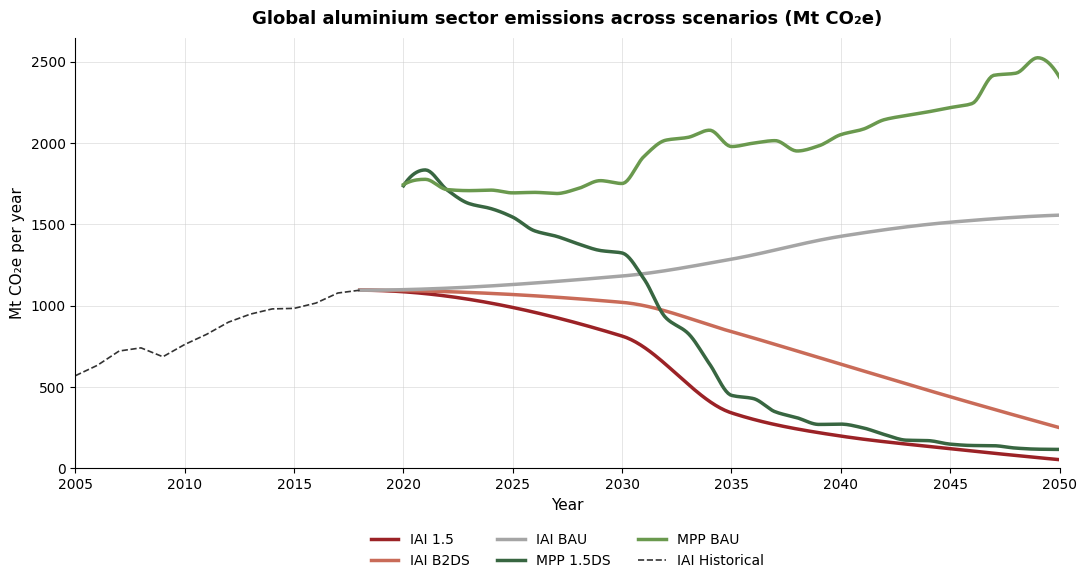

In [5]:
# Emissions comparison: IAI three scenarios + MPP two scenarios
fig, ax = plt.subplots(figsize=(11, 6))

# IAI scenarios (5-yr grid)
for scen, col in [("IAI 1.5", "IAI 1.5"), ("IAI B2DS", "IAI B2DS"), ("IAI BAU", "IAI BAU")]:
    x, y = smooth_line(iai_emissions["year"].values, iai_emissions[col].values)
    ax.plot(x, y, color=COLORS[scen], linewidth=2.5, label=scen)

# MPP scenarios (annual)
for scen in ["MPP 1.5DS", "MPP BAU"]:
    y = mpp_emissions_wide[scen].values
    x, ys = smooth_line(mpp_emissions_wide["year"].values, y)
    ax.plot(x, ys, color=COLORS[scen], linewidth=2.5, label=scen)

# IAI historical for context
ax.plot(iai_hist["year"], iai_hist["Aluminium Sector Mt CO2e"],
        color="#333333", linewidth=1.2, linestyle="--", label="IAI Historical")

ax.set_title("Global aluminium sector emissions across scenarios (Mt CO₂e)")
ax.set_xlabel("Year")
ax.set_ylabel("Mt CO₂e per year")
ax.set_xlim(2005, 2050)
ax.set_xticks(range(2005, 2051, 5))
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

## 3. Global primary aluminium intensity

Intensity trajectories from IAI (process emissions only, tCO₂e / t primary Al) and MPP (total emissions per t aluminium, includes power and refining).

**Note**: IAI is process-only (excludes electricity), so its numerator is much smaller. MPP is closer to full cradle-to-gate. Do not read the level difference as a discrepancy — the scopes differ.

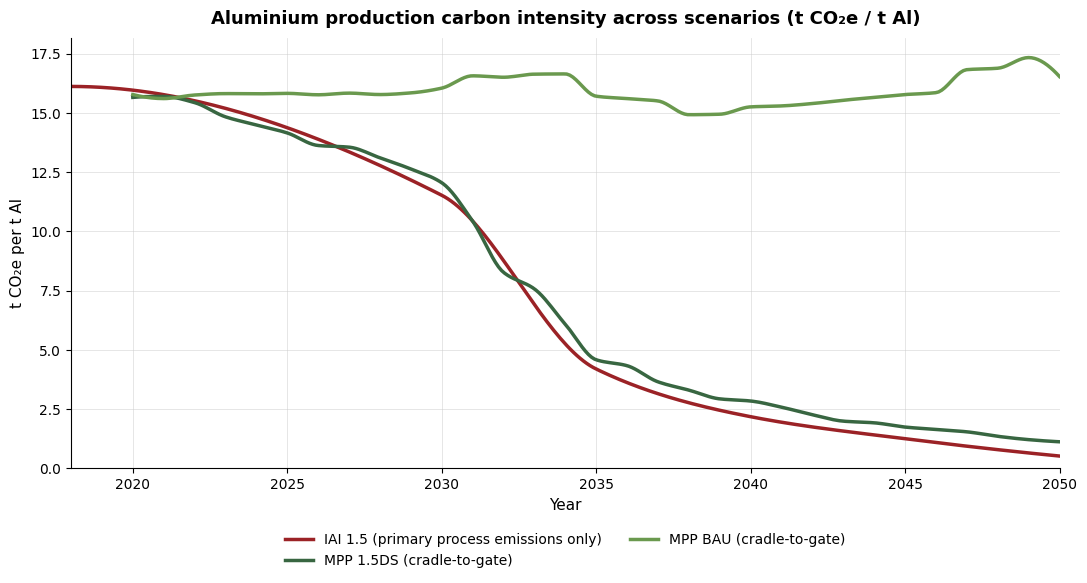

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

# IAI Primary Aluminium intensity (process emissions)
x, y = smooth_line(iai_intensity_primary_15["year"].values,
                   iai_intensity_primary_15["IAI 1.5"].values)
ax.plot(x, y, color=COLORS["IAI 1.5"], linewidth=2.5,
        label="IAI 1.5 (primary process emissions only)")

# MPP total intensity
for scen in ["MPP 1.5DS", "MPP BAU"]:
    x, y = smooth_line(mpp_intensity_wide["year"].values, mpp_intensity_wide[scen].values)
    ax.plot(x, y, color=COLORS[scen], linewidth=2.5, label=f"{scen} (cradle-to-gate)")

ax.set_title("Aluminium production carbon intensity across scenarios (t CO₂e / t Al)")
ax.set_xlabel("Year")
ax.set_ylabel("t CO₂e per t Al")
ax.set_xlim(2018, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## 4. Global aluminium production

Activity trajectory (Mt aluminium per year). All three sources track production; boundaries do not differ here.

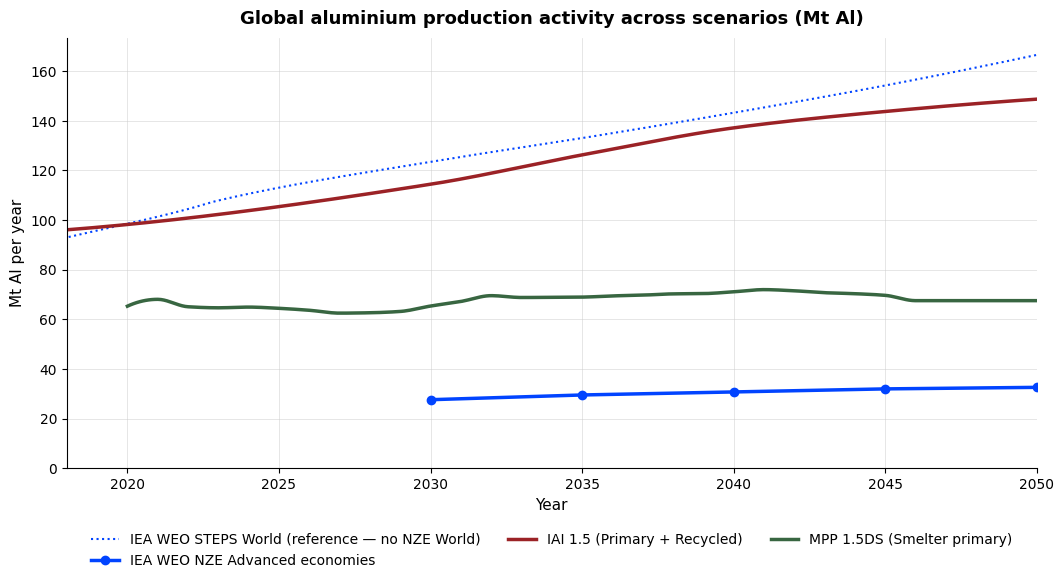

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

# WEO NZE only covers Advanced economies for aluminium production.
# For a global comparison we plot WEO STEPS World here as a reference, and
# overlay NZE Advanced economies separately.
x, y = smooth_line(weo_steps_pivot["year"].values, weo_steps_pivot["World"].values)
ax.plot(x, y, color=COLORS["IEA WEO NZE 2024"], linewidth=1.5, linestyle=":",
        label="IEA WEO STEPS World (reference — no NZE World)")

nze_ae = weo_nze[weo_nze["REGION"] == "Advanced economies"].sort_values("YEAR")
ax.plot(nze_ae["YEAR"], nze_ae["VALUE"], color=COLORS["IEA WEO NZE 2024"],
        linewidth=2.5, marker="o", label="IEA WEO NZE Advanced economies")

# IAI 1.5 total production (primary + recycled)
x, y = smooth_line(iai_production_15["year"].values, iai_production_15["Total"].values)
ax.plot(x, y, color=COLORS["IAI 1.5"], linewidth=2.5,
        label="IAI 1.5 (Primary + Recycled)")

# MPP 1.5DS total production (sum smelter + refinery? use smelter as primary metric)
mpp_smelter = mpp_prod[(mpp_prod["plant_type"] == "Smelter") & (mpp_prod["scenario"] == "1.5DS")]
mpp_smelter_year = mpp_smelter.groupby("year", as_index=False)["value"].sum()
x, y = smooth_line(mpp_smelter_year["year"].values, mpp_smelter_year["value"].values)
ax.plot(x, y, color=COLORS["MPP 1.5DS"], linewidth=2.5,
        label="MPP 1.5DS (Smelter primary)")

ax.set_title("Global aluminium production activity across scenarios (Mt Al)")
ax.set_xlabel("Year")
ax.set_ylabel("Mt Al per year")
ax.set_xlim(2018, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

## 5. Regional aluminium production (IEA WEO)

**Important limitation**: WEO 2024 Extended Regions reports NZE aluminium production for `Advanced economies` only (5 rows, 2030→2050). STEPS and APS have full 19-region coverage but are not the 1.5°C-aligned scenario.

Shown below: STEPS regional split (as reference for the *shape* of regional demand) with NZE Advanced economies overlaid. This is the same limitation flagged for the global figure above.

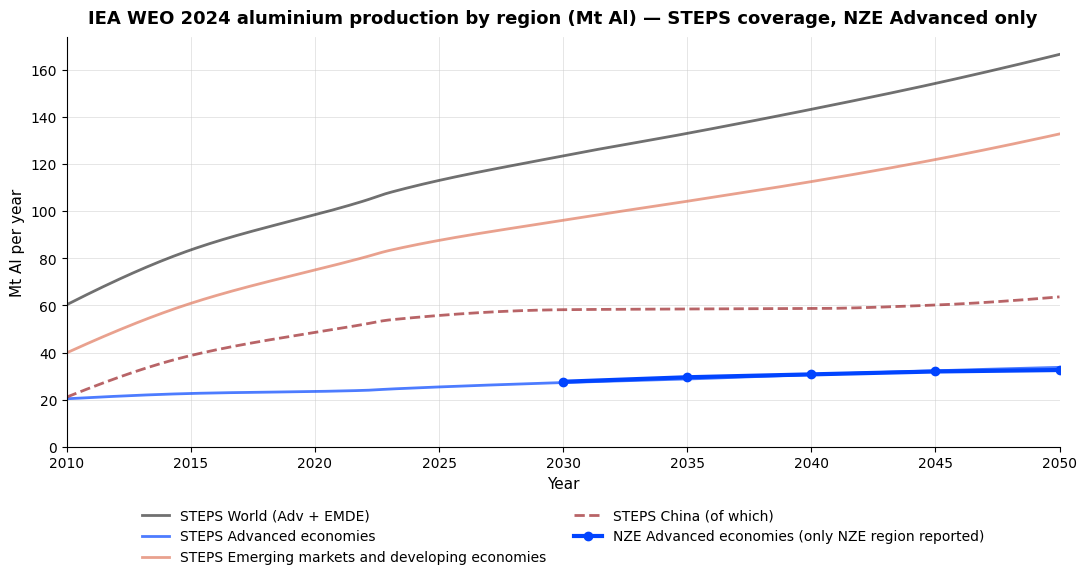

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

region_colors = {
    "Advanced economies": "#0144ff",
    "Emerging market and developing economies": "#e07a5f",
    "China": "#9b2226",
    "World": "#333333",
}
region_labels = {
    "Advanced economies": "STEPS Advanced economies",
    "Emerging market and developing economies": "STEPS Emerging markets and developing economies",
    "China": "STEPS China (of which)",
    "World": "STEPS World (Adv + EMDE)",
}

for reg in ["World", "Advanced economies", "Emerging market and developing economies", "China"]:
    x, y = smooth_line(weo_steps_pivot["year"].values, weo_steps_pivot[reg].values)
    linestyle = "--" if reg == "China" else "-"
    ax.plot(x, y, color=region_colors[reg], linewidth=2.0,
            linestyle=linestyle, label=region_labels[reg], alpha=0.7)

# Overlay NZE Advanced economies
nze_ae = weo_nze[weo_nze["REGION"] == "Advanced economies"].sort_values("YEAR")
ax.plot(nze_ae["YEAR"], nze_ae["VALUE"], color=region_colors["Advanced economies"],
        linewidth=3.0, marker="o", label="NZE Advanced economies (only NZE region reported)")

ax.set_title("IEA WEO 2024 aluminium production by region (Mt Al) — STEPS coverage, NZE Advanced only")
ax.set_xlabel("Year")
ax.set_ylabel("Mt Al per year")
ax.set_xlim(2010, 2050)
ax.set_xticks(range(2010, 2051, 5))
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## 6. MPP technology mix (global smelter output)

MPP resolves smelter output by anode technology and electricity source. Grouped view here shows how the 1.5DS scenario reallocates output across archetypes. This is what makes MPP essential for the P2 (share of low-carbon aluminium) and P3 (asset transition milestone) pathways.

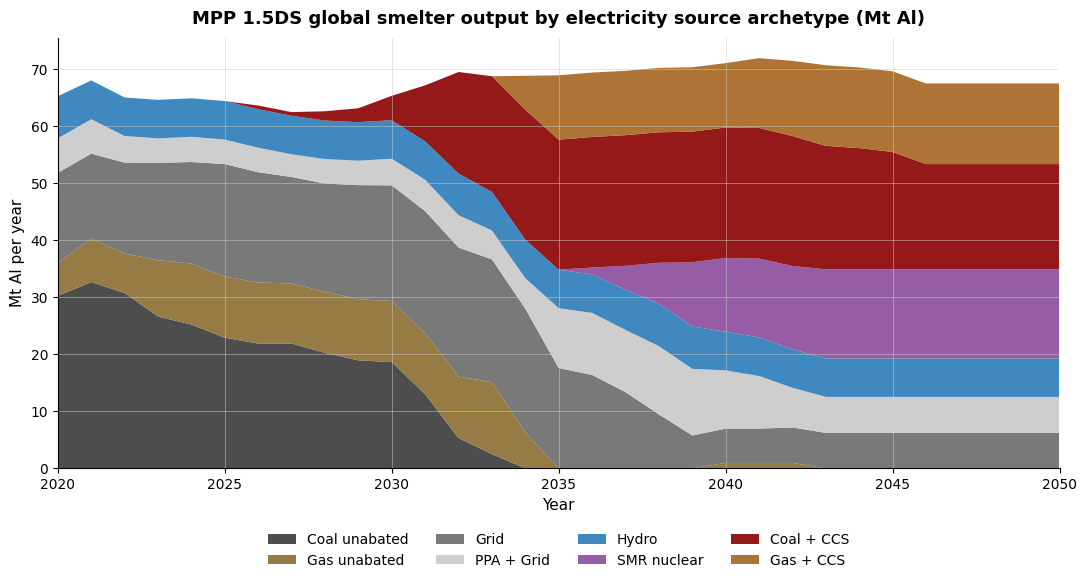

In [9]:
# Group the 36 MPP smelter technologies into archetypes for readability
def classify_tech(t):
    anode = "Inert" if "Inert Anode" in t else ("Carbon+CCS" if "Carbon Anode+CCS" in t else "Carbon")
    if "Coal+CCS" in t:
        power = "Coal + CCS"
    elif "Coal" in t:
        power = "Coal unabated"
    elif "Natural Gas+CCS" in t:
        power = "Gas + CCS"
    elif "Natural Gas" in t:
        power = "Gas unabated"
    elif "Hydro" in t:
        power = "Hydro"
    elif "Small Modular Reactor" in t:
        power = "SMR nuclear"
    elif "PPA" in t:
        power = "PPA + Grid"
    elif "Grid" in t:
        power = "Grid"
    else:
        power = "Other"
    return anode, power

smel = mpp_prod[(mpp_prod["plant_type"] == "Smelter") & (mpp_prod["scenario"] == "1.5DS")].copy()
smel[["anode", "power"]] = smel["technology"].apply(lambda t: pd.Series(classify_tech(t)))

# Aggregate to power-source archetype (anode differences are visible in a separate figure)
by_power = smel.groupby(["year", "power"], as_index=False)["value"].sum()
pivot_power = by_power.pivot(index="year", columns="power", values="value").fillna(0)
power_order = ["Coal unabated", "Gas unabated", "Grid", "PPA + Grid",
               "Hydro", "SMR nuclear", "Coal + CCS", "Gas + CCS"]
pivot_power = pivot_power[[c for c in power_order if c in pivot_power.columns]]

fig, ax = plt.subplots(figsize=(11, 6))
palette = ["#3a3a3a", "#8c6d31", "#6b6b6b", "#c9c9c9",
           "#2b7bba", "#8b4a9c", "#8b0000", "#a5651f"]
ax.stackplot(pivot_power.index, pivot_power.values.T,
             labels=pivot_power.columns, colors=palette[:pivot_power.shape[1]], alpha=0.9)
ax.set_title("MPP 1.5DS global smelter output by electricity source archetype (Mt Al)")
ax.set_xlabel("Year")
ax.set_ylabel("Mt Al per year")
ax.set_xlim(2020, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

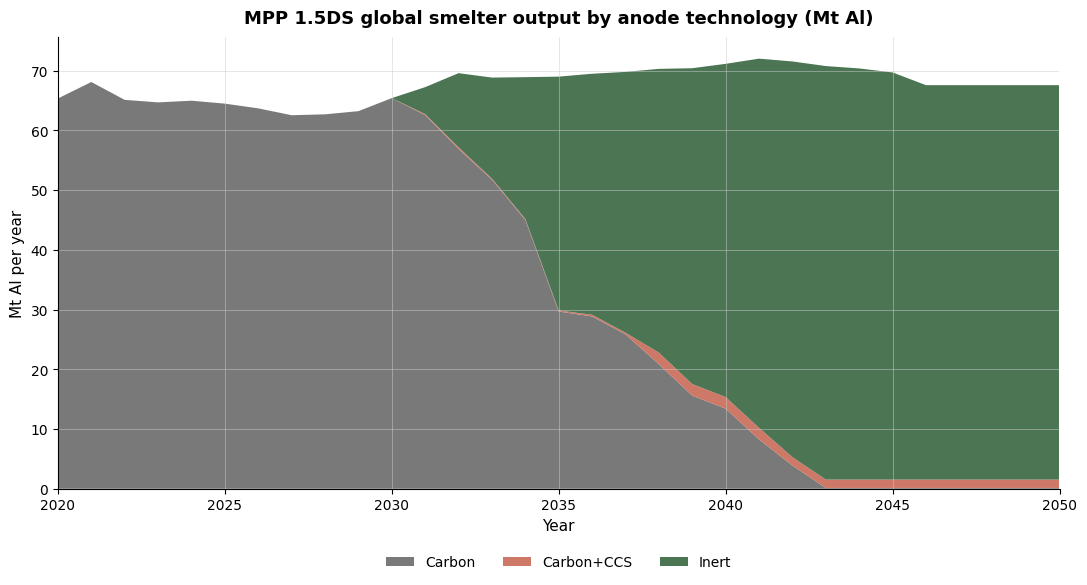

In [10]:
# Anode technology mix (Carbon vs Inert vs Carbon+CCS)
by_anode = smel.groupby(["year", "anode"], as_index=False)["value"].sum()
pivot_anode = by_anode.pivot(index="year", columns="anode", values="value").fillna(0)
anode_order = ["Carbon", "Carbon+CCS", "Inert"]
pivot_anode = pivot_anode[[c for c in anode_order if c in pivot_anode.columns]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.stackplot(pivot_anode.index, pivot_anode.values.T,
             labels=pivot_anode.columns, colors=["#6b6b6b", "#c96b58", "#386641"], alpha=0.9)
ax.set_title("MPP 1.5DS global smelter output by anode technology (Mt Al)")
ax.set_xlabel("Year")
ax.set_ylabel("Mt Al per year")
ax.set_xlim(2020, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

## 7. Source × pathway coverage summary

| | **P1 Emissions/intensity** | **P2 Alignment (low-C share)** | **P3 Asset transition milestones** |
|---|---|---|---|
| **IEA WEO NZE 2024** | **NZE aluminium production is Advanced-only in the extended file (5 rows).** STEPS/APS cover 19 regions but are not 1.5°C. Emissions and intensity not disaggregated by aluminium anywhere. | Denominator only, and only for AE under NZE. | Not derivable from extended file. |
| **IAI 1.5** | Rich process split (S1/S2), global only, 5-yr grid. | Global only — supports "share recycled" and "share primary below X" as global metrics. | No asset stack, no tech archetypes. |
| **MPP 1.5DS** | Global outputs in xlsx; regional emissions require re-running the model. Country-level asset stack in the repo enables AE/EMDE re-aggregation. | 36 tech archetypes distinguish inert-anode and low-carbon-power routes; near-zero threshold definable. | Only viable source. Country-level fleet, tech transitions, technology moratorium logic. |

### Recommendation
- **P1**: Anchor to IEA NZE aluminium sector budget (global). Validate against IAI process split. Build the AE/EMDE trajectory from MPP with country-level re-aggregation.
- **P2**: MPP for the tech-archetype classification and regional share. IAI as global cross-check.
- **P3**: MPP only. Re-map country-level asset stack to AE/EMDE/China.

### Open gaps
- IEA-native aluminium sector emissions at AE/EMDE resolution not in local files. May exist in IEA ETP or IEA Aluminium tracking data; access needed.
- MPP config carbon budget does not explicitly cite IEA NZE anchor. Traceability documented in MPP report text (not in the repo). Needs verification.
- IAI cannot contribute at AE/EMDE resolution or to milestones.